forge数据集信息
数据形状:(26, 2)
标签:[1 0 1 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 0 1 0]
类别:{np.int64(0), np.int64(1)}


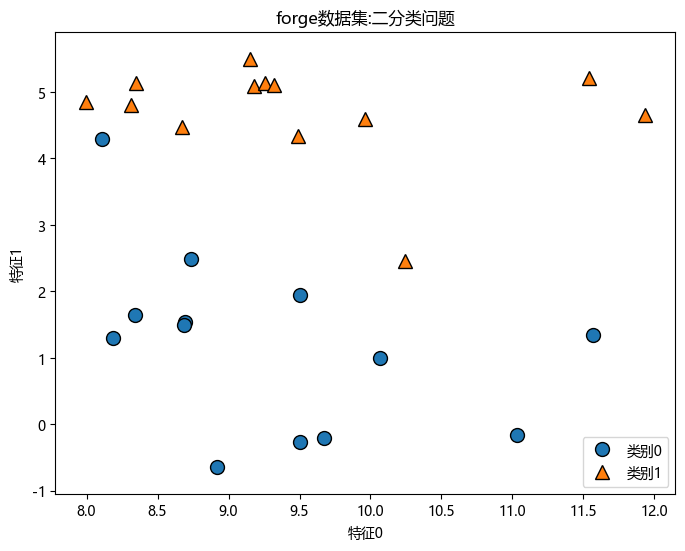

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

X,y = mglearn.datasets.make_forge()

print("="*50)
print("forge数据集信息")
print("="*50)
print(f"数据形状:{X.shape}")
print(f"标签:{y}")
print(f"类别:{set(y)}")

plt.figure(figsize=(8,6))
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel('特征0')
plt.ylabel('特征1')
plt.legend(['类别0','类别1'],loc=4)
plt.title('forge数据集:二分类问题')
plt.show()

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

logreg = LogisticRegression(C=1)
logreg.fit(X,y)

linearsvc = LinearSVC(C=1,dual='auto')
linearsvc.fit(X,y)

print("="*50)
print("线性分类器参数")
print("="*50)
print(f"LogisticRegression 系数:{logreg.coef_}")
print(f"LogisticRegression 截距:{logreg.intercept_}")
print(f"\nLinearSVC 系数:{linearsvc.coef_}")
print(f"LinearSVC 截距:{linearsvc.intercept_}")

线性分类器参数
LogisticRegression 系数:[[0.6728714  1.53137914]]
LogisticRegression 截距:[-11.09738878]

LinearSVC 系数:[[-0.04571806  0.49727211]]
LinearSVC 截距:[-1.13098563]


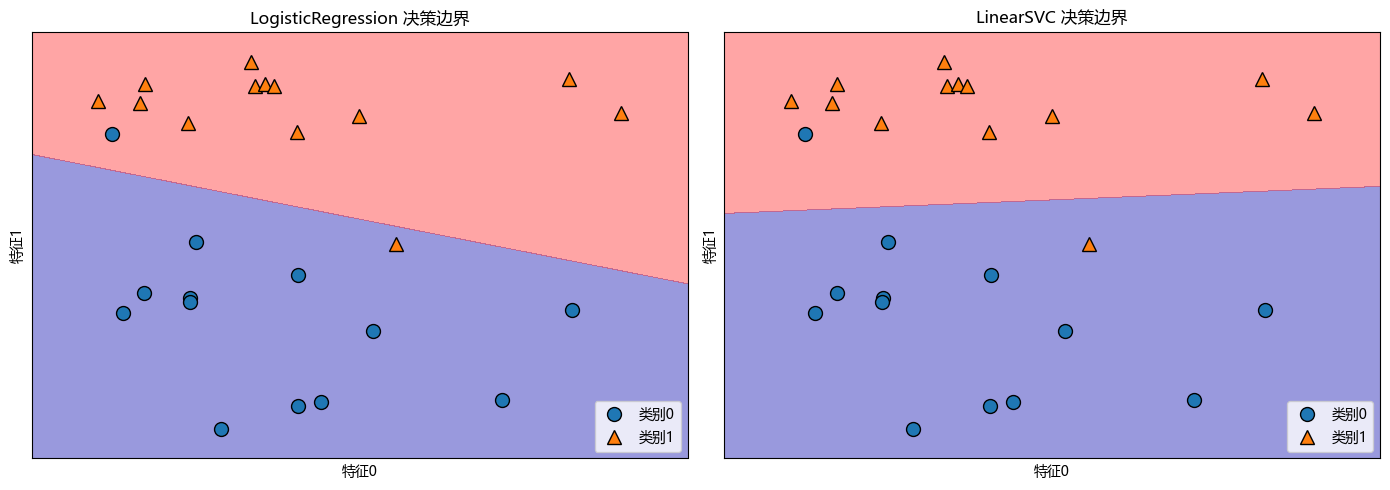

观察:两个模型都找到了用直线分割两个类别的方法


In [5]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

mglearn.plots.plot_2d_separator(logreg,X,fill=True,eps=0.5,ax=axes[0],alpha=0.4)
mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=axes[0])
axes[0].set_title('LogisticRegression 决策边界')
axes[0].set_xlabel('特征0')
axes[0].set_ylabel('特征1')

mglearn.plots.plot_2d_separator(linearsvc,X,fill=True,eps=0.5,ax=axes[1],alpha=0.4)
mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=axes[1])
axes[1].set_title('LinearSVC 决策边界')
axes[1].set_xlabel('特征0')
axes[1].set_ylabel('特征1')

axes[0].legend(['类别0','类别1'],loc='lower right')
axes[1].legend(['类别0','类别1'],loc='lower right')
plt.tight_layout()
plt.show()

print("观察:两个模型都找到了用直线分割两个类别的方法")

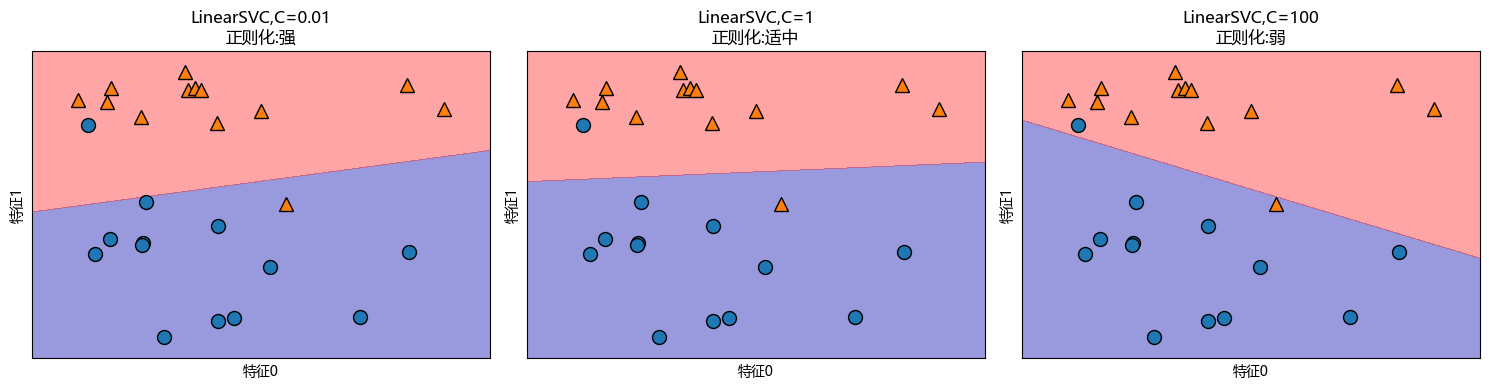

C参数观察
C=0.01(强正则化):决策边界平滑，允许一些分类错误
C=1(适中)：平衡
C=100(弱正则化):决策边界复杂，尽量把所有点分类正确


In [8]:
C_values = [0.01,1,100]

fig,axes = plt.subplots(1,3,figsize=(15,4))

for C,ax in zip(C_values,axes):
    svc = LinearSVC(C=C,dual='auto',random_state=42)
    svc.fit(X,y)

    mglearn.plots.plot_2d_separator(svc,X,fill=True,eps=0.5,ax=ax,alpha=0.4)
    mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=ax)
    ax.set_title(f'LinearSVC,C={C}\n正则化:{"弱" if C>1 else "适中" if C == 1 else "强"}')
    ax.set_xlabel('特征0')
    ax.set_ylabel('特征1')

plt.tight_layout()
plt.show()

print("="*50)
print("C参数观察")
print("="*50)
print("C=0.01(强正则化):决策边界平滑，允许一些分类错误")
print("C=1(适中)：平衡")
print("C=100(弱正则化):决策边界复杂，尽量把所有点分类正确")


In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(
    cancer.data,cancer.target,random_state=42,stratify=cancer.target)

print("="*50)
print("乳腺癌数据集")
print("="*50)
print(f"样本数:{X_train.shape[0]}+{X_test.shape[0]}={X_train.shape[0]+X_test.shape[0]}")
print(f"特征数:{X_train.shape[1]}")
print(f"类别:良性={np.sum(y_train==0)}个，恶性={np.sum(y_train==1)}个")

C_values = [0.01,0.1,1,10,100]

print("\n" + "=" *50)
print("不同C值的LogisticRegression性能")
print("="*50)
print(f"{'C':<8}{'训练集精度':<12}{'测试集精度':<12}")
print("-"*35)

for C in C_values:
    logreg = LogisticRegression(C=C,max_iter=10000)
    logreg.fit(X_train,y_train)
    train_score=logreg.score(X_train,y_train)
    test_score = logreg.score(X_test,y_test)
    print(f"{C:<8}{train_score:<12.4f}{test_score:<12.4f}")

乳腺癌数据集
样本数:426+143=569
特征数:30
类别:良性=159个，恶性=267个

不同C值的LogisticRegression性能
C       训练集精度       测试集精度       
-----------------------------------
0.01    0.9531      0.9510      
0.1     0.9507      0.9510      
1       0.9577      0.9580      
10      0.9742      0.9650      
100     0.9789      0.9650      


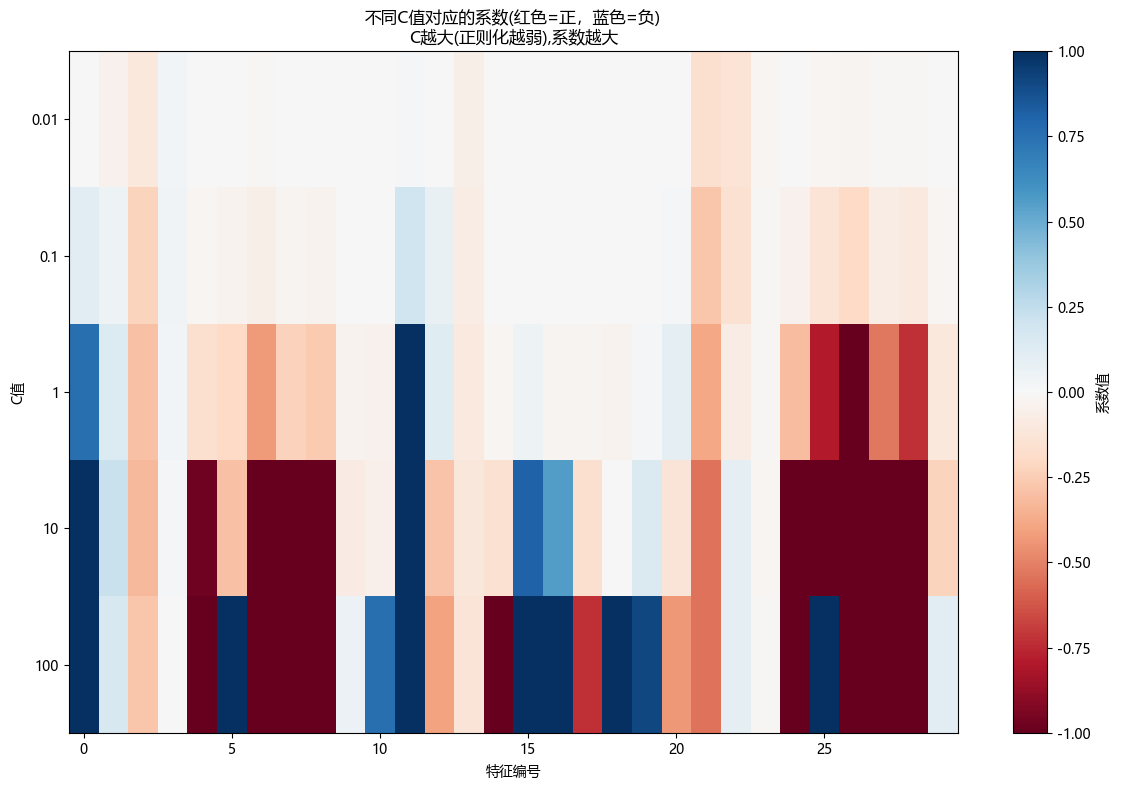

观察:C越小(正则化越强)，系数越接近0
C越大(正则化越弱),系数绝对值越大


In [15]:
C_values = [0.01,0.1,1,10,100]
coefs=[]

for C in C_values:
    logreg = LogisticRegression(C=C,max_iter=10000)
    logreg.fit(X_train,y_train)
    coefs.append(logreg.coef_[0])

coefs = np.array(coefs)

plt.figure(figsize=(12,8))
plt.imshow(coefs,cmap='RdBu',vmin=-1,vmax=1,aspect='auto')
plt.colorbar(label='系数值')
plt.xlabel('特征编号')
plt.ylabel('C值')
plt.yticks(range(len(C_values)),C_values)
plt.title('不同C值对应的系数(红色=正，蓝色=负)\nC越大(正则化越弱),系数越大')
plt.tight_layout()
plt.show()

print("观察:C越小(正则化越强)，系数越接近0")
print("C越大(正则化越弱),系数绝对值越大")